In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
decoded_variables= { 'photostim', 'shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22]
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,6,8,9,10,11,12,13,15,16,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #1
remove_indices = [0,1,2,6,8,9,10,11,16,19,22,24] #7 no outcome

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HA10-1L', '2023-03-31', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_3nmf_pre'
#results_pre,results_pre_all = data_handler.process_multiple_datasets(datasets, model_type)
# results_pre,results_pre_all_sb, cat_results = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives each split!

model_type = 'GLM_3nmf_passive'
#results_pass,results_pass_all = data_handler.process_multiple_datasets(datasets, model_type)
results_pass,results_pass_all_sb, cat_results = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA2-1L_2023-05-05
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/1_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/2_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/3_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/4_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/5_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/6_1/
decoder_results_regular_photostim.mat
decoder_results_shuffled_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/dec

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [7]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [8]:
def create_shuffled_distribution_structure(cat_results, decoder_type='sound_category'):
    """Create a structure for frames x neurons x all shuffles (500 total shuffles across 10 folds)."""
    shuffled_structure = {}
    for dataset in cat_results:
        print(dataset)
        shuffled_structure[dataset] = []
        # Process each fold
        for fold_num in range(1, 11):  # Assuming folds are labeled 1 to 10
            fold_key = f'fold_{fold_num}'
            # Extract the shuffled data for the specific decoder type and fold
            shuffled_data = cat_results[dataset][f'shuffled/{decoder_type}'][fold_num - 1]['sc_instantaneous_information']
            # Append the shuffled data (50 shuffles per fold) to the list
            shuffled_structure[dataset].append(shuffled_data)
        # After all folds are processed, concatenate the data into a single array of shape (frames x neurons x all_shuffles)
        shuffled_structure[dataset] = np.concatenate(shuffled_structure[dataset], axis=2)
    return shuffled_structure

In [9]:
shuffled_structure = create_shuffled_distribution_structure(cat_results, decoder_type='photostim')
#np.shape(shuffled_structure['HA1-00_2023-06-29'])

HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-24
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_decoding_results(mean_results_all, decoder_type='choice', plot_type='pop', save_dir=None, xlim = None, ylim = None):
    """
    Plot mean decoding results across datasets.
    
    Args:
        mean_results_all (dict): Dictionary of mean results across datasets
        decoder_type (str): Type of decoding ('choice', 'sound_category', etc.)
        plot_type (str): 'pop' or 'sc' for population or single cell
        save_dir (str): Directory to save plots (optional)
    """
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    
    # Metrics to plot
    metrics = [
        f'{plot_type}_instantaneous_information_mean',
        f'{plot_type}_cumulative_information_mean',
        f'{plot_type}_instantaneous_fraction_correct_mean',
        f'{plot_type}_cumulative_fraction_correct_mean'
    ]

    # Get event frames from first dataset
    first_dataset = list(mean_results_all.keys())[0]
    event_frames = mean_results_all[first_dataset][decoder_type]['event_frame_mean']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flat
    
    for idx, metric in enumerate(metrics):
        # Collect data across datasets
        all_data = []
        for dataset in mean_results_all.keys():
            if decoder_type in mean_results_all[dataset]:
                data = mean_results_all[dataset][decoder_type][metric]

                # Average across neurons for sc data
                if plot_type == 'sc' and len(data.shape) == 2:  # frames x neurons
                    data = np.mean(data, axis=1)  # average across neurons

                all_data.append(data)
        
        # Calculate mean and SEM across datasets
        all_data = np.array(all_data)
        mean_trace = np.mean(all_data, axis=0)
        sem_trace = np.std(all_data, axis=0) / np.sqrt(len(all_data))
        
        # Plot
        ax = axes[idx]
        x = np.arange(len(mean_trace))
        ax.plot(mean_trace, 'k-', label='Mean')
        ax.fill_between(x, mean_trace-sem_trace, mean_trace+sem_trace, 
                       alpha=0.3, color='gray', label='SEM')
        
        # Add event markers
        if xlim is None:
            xlim = (0, len(mean_trace)) # full trace
        for frame in event_frames:
            if frame < xlim[1]:
                ax.axvline(x=frame, color='k', linestyle=':', alpha=0.5)
        
        # Formatting
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_xlabel('Frames')
        if 'information' in metric:
            ax.set_ylabel('Bits')
        else:
            ax.set_ylabel('Fraction Correct')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_box_aspect(1)
        if xlim:
            ax.set_xlim(xlim)

        if ylim:
            ax.set_ylim(0,ylim[idx])
        
    plt.tight_layout()
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, f'{decoder_type}_{plot_type}_decoding.png'))
    
    plt.show()



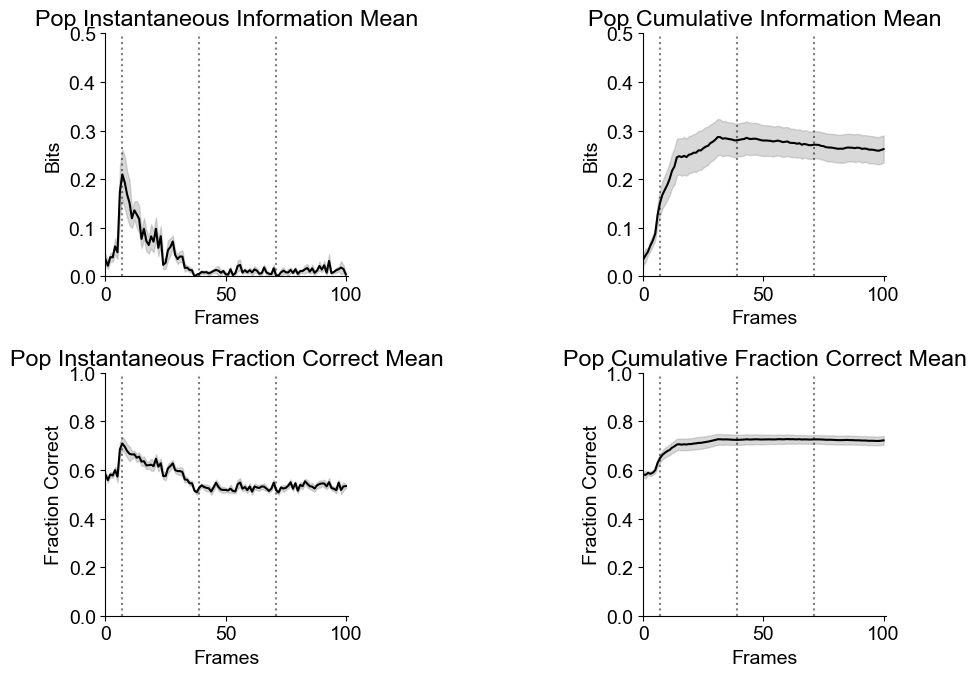

In [12]:
results_pre_all = results_pass_all_sb 
current_decoder_type = 'photostim'   
# Usage example:
plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop',
                     save_dir=plotter.save_results,
                     #xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) 

In [13]:
def analyze_peak_responses(mean_results_all, decoder_type='choice', start_frame = 14,end_frame = None):
    """Analyze peak responses for each dataset and neuron."""
    peak_analysis = {}
    
    for dataset in mean_results_all:
        peak_analysis[dataset] = {
            'sc': {},
            'pop': {}
        }
        
        # Single cell metrics
        sc_metrics = [
            'sc_instantaneous_information_mean',
            'sc_cumulative_information_mean',
            'sc_instantaneous_fraction_correct_mean',
            'sc_cumulative_fraction_correct_mean'
        ]
        
        # Population metrics
        pop_metrics = [
            'pop_instantaneous_information_mean',
            'pop_cumulative_information_mean',
            'pop_instantaneous_fraction_correct_mean',
            'pop_cumulative_fraction_correct_mean'
        ]
        
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                
                if end_frame is None:
                    end_frame = len(data)

                # For each neuron
                n_neurons = data.shape[1]
                peaks = []
                peak_frames = []
                
                for n in range(n_neurons):
                    neuron_data = data[start_frame:end_frame, n]
                    peak_val = np.max(neuron_data)
                    peak_frame = np.argmax(neuron_data) + start_frame
                    peaks.append(peak_val)
                    peak_frames.append(peak_frame)
                    
                peak_analysis[dataset]['sc'][metric] = {
                    'peak_values': np.array(peaks),
                    'peak_frames': np.array(peak_frames)
                }
        
        # Population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:

                if end_frame is None:
                    end_frame = len(data)
                    
                data = mean_results_all[dataset][decoder_type][metric]
                peak_val = np.max(data[start_frame:end_frame])
                peak_frame = np.argmax(data[start_frame:end_frame]) + start_frame
                
                peak_analysis[dataset]['pop'][metric] = {
                    'peak_value': peak_val,
                    'peak_frame': peak_frame
                }
    
    return peak_analysis

# # Usage:
# peaks = analyze_peak_responses(results_pre_all, decoder_type='sound_category', start_frame=14)

# # Print example results
# dataset = list(peaks.keys())[0]
# print(f"\nDataset: {dataset}")
# print("\nSingle cell peaks (first 5 neurons):")
# for metric in peaks[dataset]['sc']:
#     print(f"\n{metric}:")
#     print(f"Peak values: {peaks[dataset]['sc'][metric]['peak_values'][:5]}")
#     print(f"Peak frames: {peaks[dataset]['sc'][metric]['peak_frames'][:5]}")

# print("\nPopulation peaks:")
# for metric in peaks[dataset]['pop']:
#     print(f"\n{metric}:")
#     print(f"Peak value: {peaks[dataset]['pop'][metric]['peak_value']}")
#     print(f"Peak frame: {peaks[dataset]['pop'][metric]['peak_frame']}")

In [14]:
def analyze_peak_responses(mean_results_all, decoder_type='choice', start_frame=14, end_frame=None, significance_threshold=0.95):
    """Analyze peak responses for each dataset and neuron, flagging significantly informative neurons."""
    peak_analysis = {}
    for dataset in mean_results_all:
        peak_analysis[dataset] = {
            'sc': {},
            'pop': {}
        }
        # Single cell metrics
        sc_metrics = [
            'sc_instantaneous_information_mean',
            'sc_cumulative_information_mean',
            'sc_instantaneous_fraction_correct_mean',
            'sc_cumulative_fraction_correct_mean'
        ]
        # Population metrics
        pop_metrics = [
            'pop_instantaneous_information_mean',
            'pop_cumulative_information_mean',
            'pop_instantaneous_fraction_correct_mean',
            'pop_cumulative_fraction_correct_mean'
        ]
        # Analyze single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                if end_frame is None:
                    end_frame = len(data)
                n_neurons = data.shape[1]
                peaks = []
                peak_frames = []
                significant_neurons = []  # To track significant neurons for this metric
                # Retrieve shuffled data for comparison
                shuffled_data = mean_results_all[dataset][f'shuffled/{decoder_type}']
                for n in range(n_neurons):
                    neuron_data = data[start_frame:end_frame, n]
                    # Compute the peak value and peak frame for the neuron
                    peak_val = np.max(neuron_data)
                    peak_frame = np.argmax(neuron_data) + start_frame
                    # Retrieve the corresponding shuffled data for this neuron
                    shuffled_neuron_data = shuffled_data[start_frame:end_frame, n]
                    # Compute the peak values for the shuffled distribution
                    shuffled_peaks = np.max(shuffled_neuron_data, axis=0)
                    # Compute the 95th percentile of the shuffled peak values
                    shuffled_95th_percentile = np.percentile(shuffled_peaks, 95)
                    # Flag the neuron as significant if the peak value exceeds the 95th percentile
                    is_significant = peak_val > shuffled_95th_percentile
                    peaks.append(peak_val)
                    peak_frames.append(peak_frame)
                    significant_neurons.append(is_significant)
                peak_analysis[dataset]['sc'][metric] = {
                    'peak_values': np.array(peaks),
                    'peak_frames': np.array(peak_frames),
                    'significant_neurons': np.array(significant_neurons)  # Store significant neurons
                }
        # Analyze population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                if end_frame is None:
                    end_frame = len(data)
                peak_val = np.max(data[start_frame:end_frame])
                peak_frame = np.argmax(data[start_frame:end_frame]) + start_frame
                # Retrieve shuffled data for the population metric
                shuffled_data = mean_results_all[dataset][f'shuffled/{decoder_type}']
                shuffled_peaks = np.max(shuffled_data[start_frame:end_frame], axis=0)
                # Compute the 95th percentile of the shuffled peak values
                shuffled_95th_percentile = np.percentile(shuffled_peaks, 95)
                # Flag the population as significant if the peak value exceeds the 95th percentile
                is_significant = peak_val > shuffled_95th_percentile
                peak_analysis[dataset]['pop'][metric] = {
                    'peak_value': peak_val,
                    'peak_frame': peak_frame,
                    'is_significant': is_significant  # Store significance for population
                }
    return peak_analysis

In [16]:
# class DecodingAnalyzer:
#     def __init__(self):
#         self.cell_types = ['pyr', 'som', 'pv']
#         self.metrics = {
#             'sc': ['sc_instantaneous_information_mean',
#                   'sc_cumulative_information_mean',
#                   'sc_instantaneous_fraction_correct_mean',
#                   'sc_cumulative_fraction_correct_mean'],
#             'pop': ['pop_instantaneous_information_mean',
#                    'pop_cumulative_information_mean',
#                    'pop_instantaneous_fraction_correct_mean',
#                    'pop_cumulative_fraction_correct_mean']
#         }

def analyze_peaks_by_celltype( mean_results_all, decoder_type='sound_category', start_frame = 14,end_frame = None):
    """Analyze peak responses separated by cell type."""
    peaks_by_celltype = {
        dataset: {
            celltype: {
                'sc': {},
                'pop': {}
            } for celltype in mean_results_all[dataset]['neuron_groups']
        } for dataset in mean_results_all
    }


    # Single cell metrics
    sc_metrics = [
        'sc_instantaneous_information_mean',
        'sc_cumulative_information_mean',
        'sc_instantaneous_fraction_correct_mean',
        'sc_cumulative_fraction_correct_mean'
    ]

    # Population metrics
    pop_metrics = [
        'pop_instantaneous_information_mean',
        'pop_cumulative_information_mean',
        'pop_instantaneous_fraction_correct_mean',
        'pop_cumulative_fraction_correct_mean'
    ]
    
    for dataset in mean_results_all:
        celltype_array = mean_results_all[dataset]['celltype_array']
        
        # Get indices for each cell type
        celltype_indices = {
            'pyr': np.where(celltype_array == 0)[0],
            'som': np.where(celltype_array == 1)[0],
            'pv': np.where(celltype_array == 2)[0]
        }

        # Process single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                
                if end_frame is None:
                    end_frame = len(data)
                    
                for celltype, indices in celltype_indices.items():
                    peaks = []
                    peak_frames = []
                    
                    for idx in indices:
                        neuron_data = data[start_frame:end_frame, idx]
                        peak_val = np.max(neuron_data)
                        peak_frame = np.argmax(neuron_data) + start_frame
                        peaks.append(peak_val)
                        peak_frames.append(peak_frame)
                    
                    peaks_by_celltype[dataset][celltype]['sc'][metric] = {
                        'peak_values': np.array(peaks),
                        'peak_frames': np.array(peak_frames),
                        'mean_peak': np.mean(peaks),
                        'sem_peak': np.std(peaks) / np.sqrt(len(peaks)),
                    }

        # Process population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                peak_val = np.max(data[start_frame:end_frame])
                peak_frame = np.argmax(data[start_frame:end_frame]) + start_frame
                for celltype, indices in celltype_indices.items():
                    
                    peaks_by_celltype[dataset][celltype]['pop'][metric] = {
                        'peak_value': peak_val,
                        'peak_frame': peak_frame
                    }

    return peaks_by_celltype


In [17]:
def analyze_peaks_by_celltype(mean_results_all, shuffled_structure, decoder_type='sound_category', start_frame=14, end_frame=None, significance_percentile=95):
    """Analyze peak responses separated by cell type and flag significantly informative neurons."""
    peaks_by_celltype = {
        dataset: {
            celltype: {
                'sc': {},
                'pop': {}
            } for celltype in mean_results_all[dataset]['neuron_groups']
        } for dataset in mean_results_all
    }
    # Single cell metrics
    sc_metrics = [
        'sc_instantaneous_information_mean',
        'sc_cumulative_information_mean',
        'sc_instantaneous_fraction_correct_mean',
        'sc_cumulative_fraction_correct_mean'
    ]
    # Population metrics
    pop_metrics = [
        'pop_instantaneous_information_mean',
        'pop_cumulative_information_mean',
        'pop_instantaneous_fraction_correct_mean',
        'pop_cumulative_fraction_correct_mean'
    ]
    for dataset in mean_results_all:
        celltype_array = mean_results_all[dataset]['celltype_array']
        # Get indices for each cell type
        celltype_indices = {
            'pyr': np.where(celltype_array == 0)[0],
            'som': np.where(celltype_array == 1)[0],
            'pv': np.where(celltype_array == 2)[0]
        }
        # Process single cell metrics
        for metric in sc_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                if end_frame is None:
                    end_frame = len(data)
                # Retrieve shuffled data for comparison
                shuffled_data = shuffled_structure [dataset] #mean_results_all[dataset][f'shuffled/{decoder_type}'][metric]
                for celltype, indices in celltype_indices.items():
                    peaks = []
                    peak_frames = []
                    significant_neurons = []  # Track significant neurons for this metric
                    for idx in indices:
                        neuron_data = data[start_frame:end_frame, idx]
                        peak_val = np.max(neuron_data)
                        peak_frame = np.argmax(neuron_data) + start_frame
                        
                        # Compute the peak value for the shuffled distribution
                        shuffled_peak = shuffled_data[peak_frame, idx, :]
                        # Compute the 95th percentile of the shuffled peak values
                        shuffled_95th_percentile = np.percentile(shuffled_peak, significance_percentile)
                        # Flag the neuron as significant if the peak value exceeds the 95th percentile
                        is_significant = peak_val > shuffled_95th_percentile
                        peaks.append(peak_val)
                        peak_frames.append(peak_frame)
                        significant_neurons.append(is_significant)
                    peaks_by_celltype[dataset][celltype]['sc'][metric] = {
                        'peak_values': np.array(peaks),
                        'peak_frames': np.array(peak_frames),
                        'mean_peak': np.mean(peaks),
                        'sem_peak': np.std(peaks) / np.sqrt(len(peaks)),
                        'significant_neurons': np.array(significant_neurons)  # Store significance for single-cell
                    }
        # Process population metrics
        for metric in pop_metrics:
            if metric in mean_results_all[dataset][decoder_type]:
                data = mean_results_all[dataset][decoder_type][metric]
                peak_val = np.max(data[start_frame:end_frame])
                peak_frame = np.argmax(data[start_frame:end_frame]) + start_frame
                # Retrieve shuffled data for population comparison
                shuffled_data = shuffled_structure [dataset] #mean_results_all[dataset][f'shuffled/{decoder_type}'][metric]
                shuffled_peak = shuffled_data[peak_frame]
                # Compute the 95th percentile of the shuffled peak values
                shuffled_95th_percentile = np.percentile(shuffled_peak, significance_percentile)
                # Flag the population as significant if the peak value exceeds the 95th percentile
                is_significant = peak_val > shuffled_95th_percentile
                for celltype, indices in celltype_indices.items():
                    peaks_by_celltype[dataset][celltype]['pop'][metric] = {
                        'peak_value': peak_val,
                        'peak_frame': peak_frame,
                        'is_significant': is_significant  # Store significance for population
                    }
    return peaks_by_celltype

In [27]:
#DECIDE WHETHER OR NOT TO USE END FRAME
peaks_by_celltype = analyze_peaks_by_celltype( results_pre_all,shuffled_structure, decoder_type=current_decoder_type, start_frame=14, end_frame = 100,significance_percentile = 95) #, end_frame = 100

In [19]:
def format_peaks_for_cdf(peaks_by_celltype, metric='sc_instantaneous_information_mean'):
    """
    Format peaks data to match coupling index structure for CDF plotting
    
    Returns dict structure:  
    {
        'pyr': {model_type: [values]},
        'som': {model_type: [values]},
        'pv': {model_type: [values]}
    }
    """
    formatted_data = {
        'pyr': {'peaks': []},
        'som': {'peaks': []},
        'pv': {'peaks': []},
        'all': {'peaks': []}    
    }
    all_peaks = []
    cell_labels = []
    # Collect peaks across datasets
    for dataset in peaks_by_celltype:
        for celltype in ['pyr', 'som', 'pv']:
            peak_values = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values']
            formatted_data[celltype]['peaks'].extend(peak_values)
            all_peaks.extend(peak_values)
            cell_labels.extend([celltype] * len(peak_values))
    # Format like coupling index data
    formatted_data = {'all': {'peaks': all_peaks}}

    return formatted_data, cell_labels


In [20]:

def format_peaks_for_cdf(peaks_by_celltype, metric='sc_instantaneous_information_mean'):
    """
    Format peaks data for CDF plotting, incorporating only significant neurons.
    Returns dict structure:
    {
        'pyr': {model_type: [values]},
        'som': {model_type: [values]},
        'pv': {model_type: [values]},
        'all': {model_type: [values]}
    }
    """
    formatted_data = {
        'pyr': {'peaks': []},
        'som': {'peaks': []},
        'pv': {'peaks': []},
        'all': {'peaks': []}
    }
    all_peaks = []
    cell_labels = []
    # Collect peaks across datasets
    for dataset in peaks_by_celltype:
        for celltype in ['pyr', 'som', 'pv']:
            peak_values = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values']
            significant_neurons = peaks_by_celltype[dataset][celltype]['sc'][metric]['significant_neurons']
            # Filter peaks for significant neurons
            significant_peaks = [peak for peak, sig in zip(peak_values, significant_neurons) if sig]
            # Append significant peaks to the formatted data
            formatted_data[celltype]['peaks'].extend(significant_peaks)
            all_peaks.extend(significant_peaks)
            cell_labels.extend([celltype] * len(significant_peaks))
    # Include all significant peaks across cell types
    formatted_data['all']['peaks'] = all_peaks
    return formatted_data, cell_labels

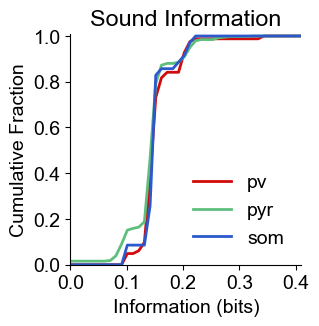

In [28]:
cdf_data, cell_labels = format_peaks_for_cdf(peaks_by_celltype)
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),cell_labels,colors = plotter.celltypecolors,title='Sound Information', xlabel = 'Information (bits)', xval=.4,xint=0.1)

In [22]:
cell_labels

['pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pv',
 'pv',
 'pv',
 'pv',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'som',
 'som',
 'som',
 'som',
 'pv',
 'pv',
 'pv',
 'pv',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'som',
 'som',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'som',
 'som',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pv',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 'pyr',
 '

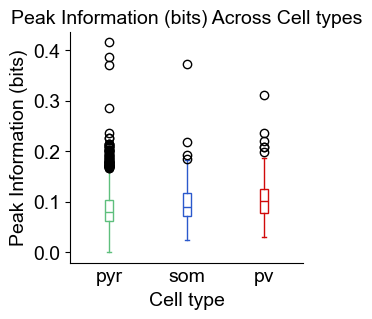

In [ ]:
def format_peaks_for_boxplot(peaks_by_celltype, metric='sc_instantaneous_information_mean'):
    # Collect all peaks and indices
    all_peaks = []
    neuron_groups = {'pyr': [], 'som': [], 'pv': []}
    current_idx = 0
    
    # Collect peaks across datasets
    for dataset in peaks_by_celltype:
        for celltype in ['pyr', 'som', 'pv']:
            peak_values = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values']
            all_peaks.extend(peak_values)
            # Store indices for this cell type
            indices = list(range(current_idx, current_idx + len(peak_values)))
            neuron_groups[celltype].extend(indices)
            current_idx += len(peak_values)
    
    return np.array(all_peaks), neuron_groups

# Usage
all_peaks, neuron_groups = format_peaks_for_boxplot(peaks_by_celltype)
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)'
)

In [ ]:
def plot_decoding_analysis(results_dict, decoder_type='sound_category'):
    """Create suite of analysis plots"""
    
    # 1. Time series plot with mean±SEM across datasets
    plt.figure(figsize=(10,6))
    all_data = []
    for dataset in results_dict:
        data = results_dict[dataset][decoder_type]['pop_cumulative_information_mean']
        all_data.append(data)
    
    mean_trace = np.mean(all_data, axis=0)
    sem_trace = np.std(all_data, axis=0) / np.sqrt(len(all_data))
    plt.plot(mean_trace, 'b-', label='Mean')
    plt.fill_between(range(len(mean_trace)), 
                    mean_trace-sem_trace, 
                    mean_trace+sem_trace,
                    alpha=0.3)
    plt.title(f'{decoder_type} Decoding Performance')
    plt.xlabel('Time (frames)')
    plt.ylabel('Information (bits)')
    
    # 2. Compare instantaneous vs cumulative
    # plt.figure(figsize=(10,6))
    # for metric in ['pop_instantaneous_information_mean', 'pop_cumulative_information_mean']:
    #     all_data = []
    #     for dataset in results_dict:
    #         data = results_dict[dataset][decoder_type][metric]
    #         all_data.append(data)
    #     mean_trace = np.mean(all_data, axis=0)
    #     plt.plot(mean_trace, label=metric.split('_')[1])
    # plt.legend()
    # plt.title('Instantaneous vs Cumulative Information')
    
    # 3. Peak information by cell type boxplot
    peaks_by_celltype = analyze_peaks_by_celltype( results_dict, decoder_type=decoder_type, start_frame=14, end_frame = 100)
    all_peaks, neuron_groups = format_peaks_for_boxplot(peaks_by_celltype)
    plotter.box_plot(all_peaks, 
                     neuron_groups,
                     plotter.celltypecolors,
                     'Peak Information')
    
    # 4. Information timeline heatmap
    plt.figure(figsize=(12,len(results_dict)))
    data_matrix = np.array([results_dict[d][decoder_type]['pop_instantaneous_information_mean'] 
                           for d in results_dict])
    sns.heatmap(data_matrix, 
                xticklabels=20, 
                yticklabels=list(results_dict.keys()),
                cmap='viridis')
    plt.title('Information Evolution Across Datasets (insta)')
    plt.xlabel('Time (frames)')
    
    plt.tight_layout()
    plt.show()


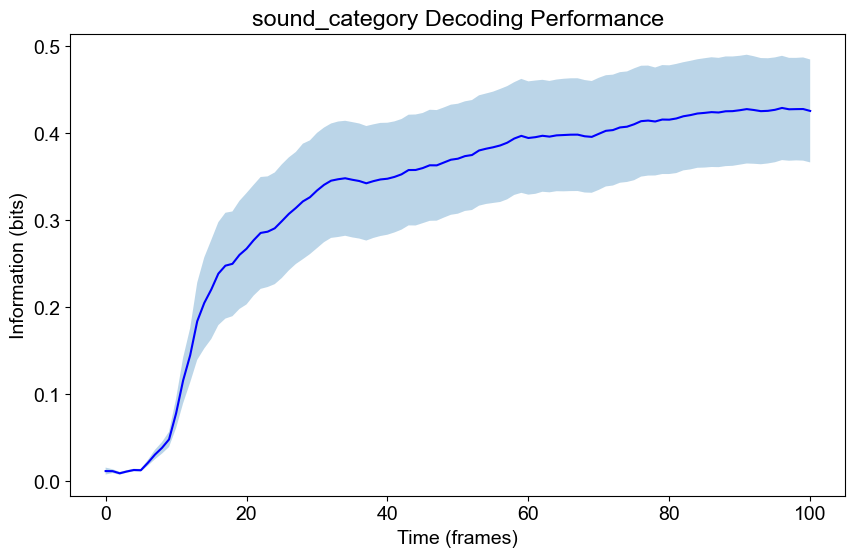

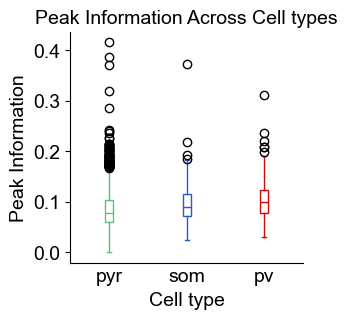

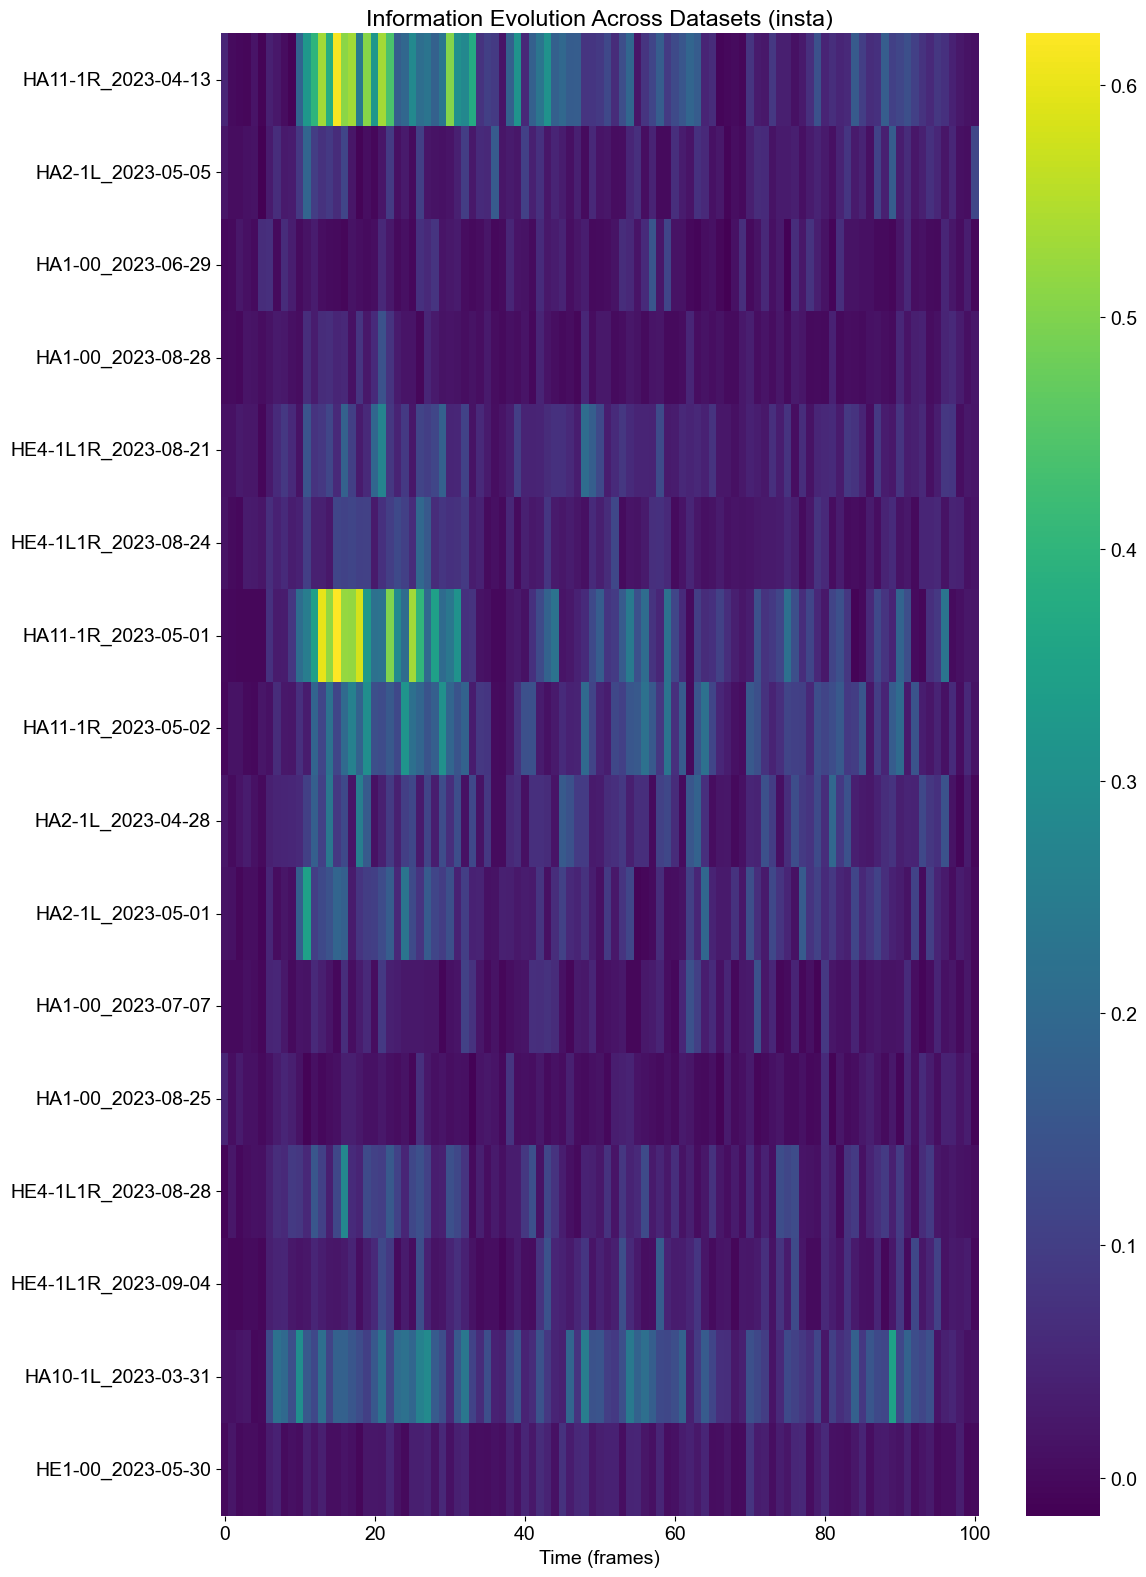

In [ ]:
plot_decoding_analysis(results_pre_all, decoder_type= 'sound_category') #current_decoder_type

In [ ]:
def plot_single_neuron_analysis(results_dict, decoder_type='sound_category', start_frame= 14, end_frame = None):
    print(start_frame)
    """Comprehensive single neuron decoding visualization"""
    
    # 1. Neuron Performance Heatmap
    plt.figure(figsize=(12, 8))
    for dataset in results_dict:
        data = results_dict[dataset][decoder_type]['sc_cumulative_information_mean']
        celltype_array = results_dict[dataset]['celltype_array']
        
        # Sort neurons by cell type and performance
        max_info = np.max(data[start_frame:, :], axis=0)
        sort_idx = np.argsort(max_info)
        
        plt.subplot(len(results_dict), 1, list(results_dict.keys()).index(dataset) + 1)
        sns.heatmap(data[:, sort_idx].T, 
                   cmap='viridis',
                   xticklabels=20,
                   yticklabels=False)
        plt.title(f'{dataset} Single Neuron Decoding')
    plt.tight_layout()
    
    # 2. Best Neurons Analysis
    # Dictionary to store neuron IDs for each dataset and cell type
    neuron_ids_by_dataset = {}
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # 1 row, 2 columns
    for cel_index,(celltype, color) in enumerate(plotter.celltypecolors.items()):
        all_peaks = []
        all_peaks_locs = []
        for dataset in results_dict:
            # Initialize a dictionary for this dataset if not already present
            if dataset not in neuron_ids_by_dataset:
                neuron_ids_by_dataset[dataset] = {}

            # Initialize a list for this cell type in the current dataset
            if celltype not in neuron_ids_by_dataset[dataset]:
                neuron_ids_by_dataset[dataset][celltype] = []
            
            peaks_by_celltype = analyze_peaks_by_celltype( results_dict, decoder_type=decoder_type, start_frame=start_frame, end_frame = end_frame)
            peaks = peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values']
            peaks_locs = peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_frames']    
            if len(peaks) > 0:
                max_peaks = sorted(peaks)  # Sorted in ascending order
                top_5 = max_peaks[-5:]     # Slice the last 5 elements (highest values)
                all_peaks.extend(top_5)

                # Get the corresponding peak locations  
                top_5_locs = [peaks_locs[max_peaks.index(p)] for p in top_5]
                # Use the indices from the sorting step to ensure uniqueness
                sorted_indices = np.argsort(peaks)
                top_5_indices = sorted_indices[-5:]  # Indices of the top 5 values
                neuron_ids_by_dataset[dataset][celltype].extend(top_5_indices.tolist())


                # Add neuron IDs (indices) to the dictionary
                #neuron_ids_by_dataset[dataset][celltype].extend(top_5_ids)

                all_peaks_locs.extend(top_5_locs)
        # Plotting histograms on subplots
        axes[0].hist(all_peaks, alpha=1.0, color=color, label=celltype, histtype='step', linewidth=2)
        axes[0].set_xlabel('Information (bits)')  # Correct method to set the x-axis label
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)
        axes[0].set_box_aspect(1)

        axes[1].hist(all_peaks_locs, alpha=1.0, color=color, label=celltype, histtype='step', linewidth=2)
        axes[1].set_xlabel('Peak Frame')  # Correct method to set the x-axis label
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        axes[1].set_box_aspect(1)

    # Add legend and title
    #fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)  # Adjust legend location
    fig.suptitle('Top 5 Neurons Distribution by Cell Type')

    # Adjust layout to avoid overlap
    plt.tight_layout() #(rect=[0, 0.03, .8, 0.95]) #(rect=[0, 0.03, 1, 0.95])  # Leave space for the title and legend

    # Show the plot
    plt.show()
    
    # 3. Time Course by Cell Type
    plt.figure(figsize=(3, 3))
    for cel_index,(celltype, color) in enumerate(plotter.celltypecolors.items()):
        all_traces = []
        for dataset in results_dict:
            if end_frame is None:
                end_frame = len(data)

            traces = results_dict[dataset][decoder_type]['sc_instantaneous_information_mean'][0:end_frame,:]

            celltype_idx = results_dict[dataset]['celltype_array'] == cel_index
            if np.any(celltype_idx):
                mean_trace = np.mean(traces[:, celltype_idx], axis=1)
                all_traces.append(mean_trace)
        
        mean = np.mean(all_traces, axis=0)
        sem = np.std(all_traces, axis=0) / np.sqrt(len(all_traces))
        plt.plot(mean, color=color, label=celltype)
        # Get the current Axes object
        ax = plt.gca()   
        ax.axvline(x = start_frame, color='k', linestyle=':', alpha=0.5)
        plt.fill_between(range(len(mean)), mean-sem, mean+sem, alpha=0.2, color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_box_aspect(1)
    
    plt.legend()
    plt.title('Average Information Time Course by Cell Type')
    plt.xlabel('Time (frames)')
    plt.ylabel('Information (bits)')
    
    plt.show()

    return neuron_ids_by_dataset


14


C:\Users\RUNYAN1\AppData\Local\Temp\ipykernel_33888\3668099757.py:21: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


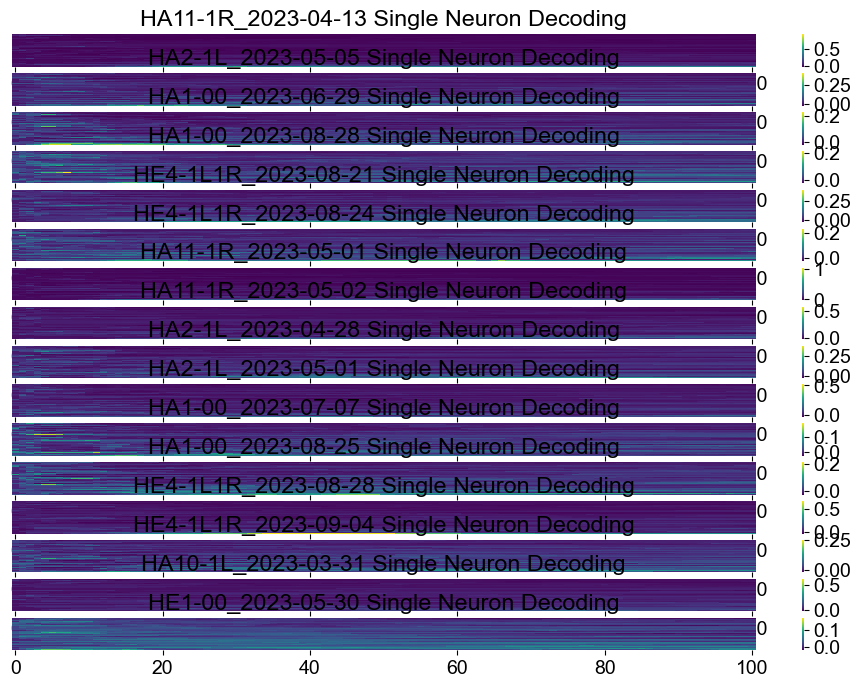

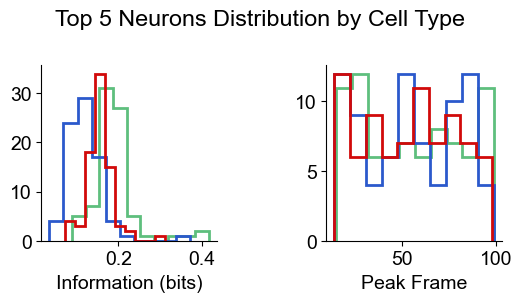

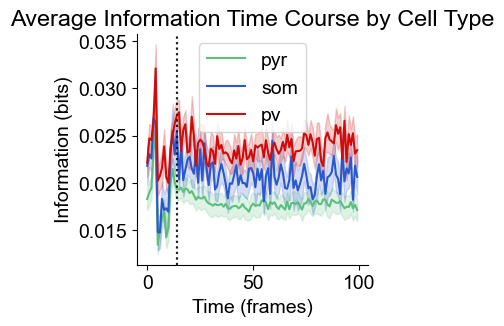

In [ ]:
neuron_ids_by_dataset = plot_single_neuron_analysis(results_pre_all, decoder_type= 'sound_category' , start_frame = 14,end_frame = 100)

In [ ]:
neuron_ids_by_dataset

{'HA11-1R_2023-04-13': {'pyr': [105, 2, 9, 338, 182],
  'som': [5, 7, 0, 4, 6],
  'pv': [1, 29, 12, 6, 13]},
 'HA2-1L_2023-05-05': {'pyr': [119, 80, 199, 156, 26],
  'som': [2, 5, 10, 13, 6],
  'pv': [10, 0, 7, 8, 1]},
 'HA1-00_2023-06-29': {'pyr': [46, 78, 25, 15, 130],
  'som': [2, 1, 5, 15, 6],
  'pv': [7, 3, 8, 9, 4]},
 'HA1-00_2023-08-28': {'pyr': [140, 80, 73, 30, 85],
  'som': [6, 1, 11, 7, 9],
  'pv': [7, 19, 3, 15, 13]},
 'HE4-1L1R_2023-08-21': {'pyr': [238, 93, 257, 42, 230],
  'som': [10, 3, 16, 5, 9],
  'pv': [13, 24, 35, 15, 6]},
 'HE4-1L1R_2023-08-24': {'pyr': [47, 103, 182, 49, 189],
  'som': [3, 2, 5, 6, 4],
  'pv': [14, 25, 1, 6, 3]},
 'HA11-1R_2023-05-01': {'pyr': [159, 267, 35, 188, 128],
  'som': [10, 16, 18, 1, 19],
  'pv': [32, 28, 11, 18, 23]},
 'HA11-1R_2023-05-02': {'pyr': [80, 205, 18, 299, 153],
  'som': [0, 6, 7, 1, 4],
  'pv': [4, 2, 0, 11, 5]},
 'HA2-1L_2023-04-28': {'pyr': [232, 71, 23, 140, 133],
  'som': [6, 1, 9, 13, 4],
  'pv': [0, 2, 8, 25, 29]},
 'H